In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Module 4: Performance and Optimizations

### Shifted-Force Potential:

In [64]:
def calculate_lj_properties(r_sq, r_cutoff_sq):
    # if(r_sq == 0): return 0
    inv_rc2 = 1.0 / r_cutoff_sq
    inv_rc6 = inv_rc2**3
    inv_rc12 = inv_rc6**2
    phi_cut = 4 * (inv_rc12 - inv_rc6)
    
    inv_r2 = 1.0 / r_sq
    inv_r6 = inv_r2**3
    inv_r12 = inv_r6**2
    
    phi = 4 * (inv_r12 - inv_r6)
    

    
    force_by_r = 48 * inv_r2 * (inv_r12 - 0.5 * inv_r6)
    force_by_rc = 48 * inv_rc2 * (inv_rc12 - 0.5 * inv_rc6)
    force_by_r = force_by_r - force_by_rc
    potE = phi - phi_cut + 0.5 * force_by_rc * (r_sq - r_cutoff_sq)

    return potE, force_by_r


### Functions defined in the previous Modules

In [65]:
def generate_fcc_lattice ( n_cells , rho_star ):

    """
    Generates an FCC lattice of atoms .
    TASK :
    1. Calculate the box length L based on density (rho = N/V).
    2. Place 4 atoms in each of the n_cells ^3 unit cells .
    """
    L = (4 * n_cells ** 3 / rho_star) ** (1 / 3)
    a = L / n_cells 
    b1 = np.array([0, 0, 0])
    b2 = np.array([a / 2, a / 2, 0])
    b3 = np.array([a / 2, 0, a / 2])
    b4 = np.array([0, a / 2, a / 2])
    positions = []
    for i in range(n_cells):
        for j in range(n_cells):
            for k in range(n_cells):
                cell_origin = np.array([i, j, k]) * (L / n_cells)
                positions.append(cell_origin + b1)
                positions.append(cell_origin + b2)
                positions.append(cell_origin + b3)
                positions.append(cell_origin + b4)

    return np.array(positions), L


# YOUR CODE HERE
def apply_minimum_image (pos_i , pos_j , L):
    """
    Calculates the shortest distance vector between two atoms .
    TASK : Use the rounding logic to ensure dx ,
    dy , and dz
    are between -L/2 and L/2.
    """
    dr = pos_j - pos_i
    dr -= L * np.round(dr / L)
    return dr

### Calculating Position, Velocity, Forces and Total PE using Shifted-Force Potential and Numpy Vectorized Functions:

In [66]:
def calculate_total_force(pos, box_length, r_cutoff_sq):
    N = len(pos)
    forces = np.zeros((N, 3))
    total_pe = 0
    dr = apply_minimum_image(pos[:, np.newaxis, :], pos[np.newaxis, :, :], box_length)
    r_sq = np.sum(dr**2, axis=2)
    r_sq = np.triu(r_sq, k=1)
    mask = (r_sq < r_cutoff_sq) & (r_sq > 0)
    pot, force_by_r = np.zeros_like(r_sq), np.zeros_like(r_sq)
    pot[mask], force_by_r[mask] = calculate_lj_properties(r_sq[mask], r_cutoff_sq)
    f_mat = force_by_r[:, :, np.newaxis] * dr
    forces += np.sum(f_mat, axis=0)
    forces -= np.sum(f_mat, axis=1)
    total_pe = np.sum(pot)

    return total_pe, forces


# Module 3 Coding Task : The Integration Engine
def velocity_verlet_step(pos, vel, force, dt, box_length, r_cutoff_sq):
    """
    Advances the system by one time step dt using Velocity Verlet.
    TASK :
    1. Update positions .
    2. Apply Periodic Boundary Conditions ( wrap atoms back into box ).
    3. Update velocities (half - step ).
    4. Calculate new forces ( This will require your Module 1 & 2 logic ).
    5. Update velocities (full - step ).
    
    pos         : (N, 3) array — current position
    vel         : (N, 3) array — current velocity
    force       : (N, 3) array — current force
    dt          : float        — time step
    box_length  : float        — box length L
    r_cutoff_sq : float        — cutoff distance squared rc²

    pos_new   : (N, 3) — updated position
    vel_new   : (N, 3) — updated velocity
    pe_new    : float  — updated potential energy
    force_new : (N, 3) — updated force
    """
    # YOUR CODE HERE

    # Step 1: New Positions
    pos_new = pos + vel * dt + 0.5 * force * dt**2
    # Step 2: PBC Wrap ( Module 2 logic )
    pos_new = pos_new % box_length
    # Step 3: Half - step velocity
    vel_mid = vel + 0.5 * force * dt
    # Step 4: New Forces ( Call your Module 1 force function here )
    pe_new, force_new = calculate_total_force(pos_new, box_length, r_cutoff_sq)
    # Step 5: Full - step velocity
    vel_new = vel_mid + 0.5 * force_new * dt

    return pos_new, vel_new, pe_new, force_new

### Testing the Verlet Integrator with the Modified Forces:

Mean E: -420.1970 | Std: 0.001234 | Relative drift: 2.94e-06


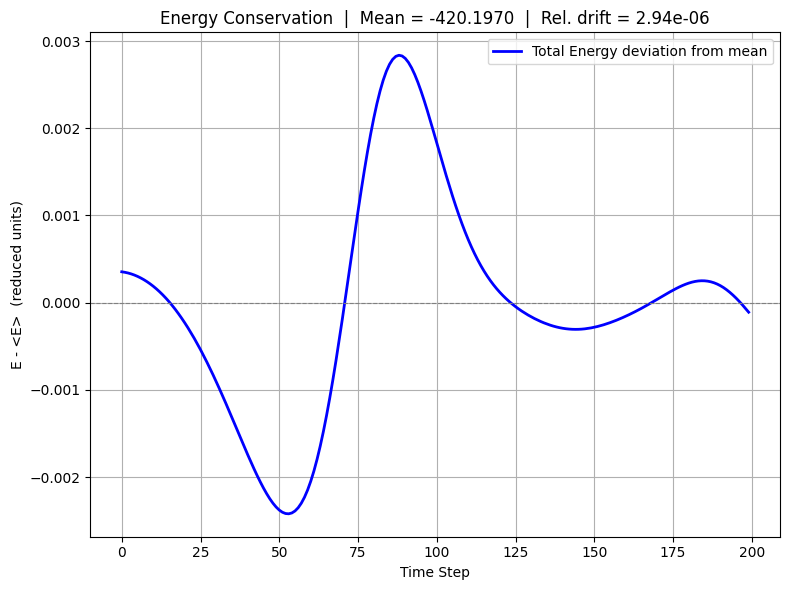

In [67]:
def calculate_kinetic_energy(vel):
    """
    K* = 0.5 * sum(v²)   [m* = 1 in reduced units]
    """
    return 0.5 * np.sum(vel**2)

# Sanity check — run ~200 steps and plot total energy
n_cells = 3           # N = 4 * 3³ = 108 atoms
rho_star = 0.8
dt = 1e-3            # safe starting value in reduced units
r_cutoff_sq = 2.5**2

pos, L = generate_fcc_lattice(n_cells, rho_star)
vel = np.random.randn(*pos.shape) * np.sqrt(1.0)   # T* ~ 1.0 initially
vel -= vel.mean(axis=0)                              # zero net momentum

pe, force = calculate_total_force(pos, L, r_cutoff_sq)

energies = []
for step in range(200):
    pos, vel, pe, force = velocity_verlet_step(pos, vel, force, dt, L, r_cutoff_sq)
    ke = calculate_kinetic_energy(vel)
    energies.append(ke + pe)

# Total energy should fluctuate < 1 part in 10⁴
E = np.array(energies)
print(f"Mean E: {E.mean():.4f} | Std: {E.std():.6f} | Relative drift: {E.std()/abs(E.mean()):.2e}")
steps = np.arange(len(E))

plt.figure(figsize=(8, 6))

# shift energy so you plot deviation from mean — much clearer
E = np.array(energies)
E_mean = E.mean()
E_deviation = E - E_mean

plt.plot(steps, E_deviation, color='blue', linewidth=2, label='Total Energy deviation from mean')

# annotate with actual numbers
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.xlabel('Time Step')
plt.ylabel('E - <E>  (reduced units)')
plt.title(f'Energy Conservation  |  Mean = {E_mean:.4f}  |  Rel. drift = {E.std()/abs(E_mean):.2e}')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

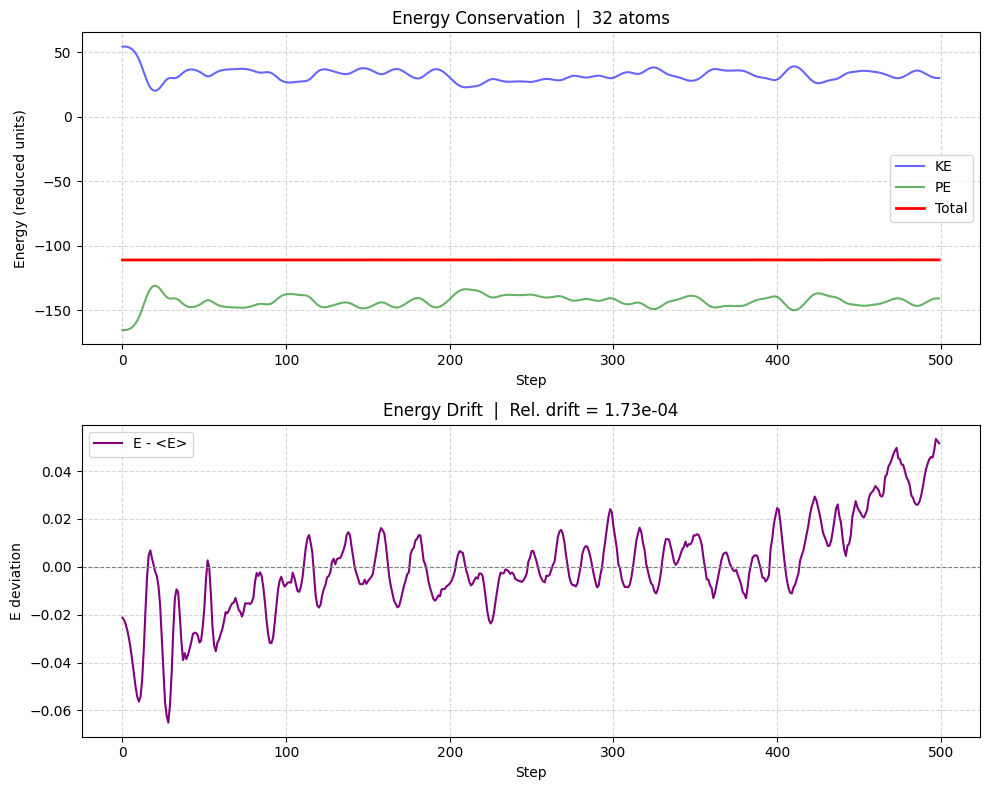

Mean E: -111.1126   Std: 0.019204   Rel drift: 1.73e-04


In [68]:
import numpy as np
import matplotlib.pyplot as plt

# --- Setup: FCC lattice with 32 atoms (n_cells=2) ---
n_cells    = 2         # 4 * 2^3 = 32 atoms
rho_star   = 0.8
r_cutoff   = 2.5;  r_cutoff_sq = r_cutoff**2   # skin > cutoff by 0.7
dt         = 0.005
n_steps    = 500

pos, L = generate_fcc_lattice(n_cells, rho_star)
vel = np.random.randn(*pos.shape) * np.sqrt(1.5)   # T* ~ 1.5
vel -= vel.mean(axis=0)

pe, force = calculate_total_force(pos, L, r_cutoff_sq)

ke_list, pe_list, total_e_list = [], [], []

for step in range(n_steps):
    pos, vel, pe, force = velocity_verlet_step(pos, vel, force, dt, L, r_cutoff_sq)
    ke = calculate_kinetic_energy(vel)
    ke_list.append(ke); pe_list.append(pe); total_e_list.append(ke + pe)
# print('Total rebuilds in', n_steps, 'steps:', rebuild_count)
# print('Rebuild at steps:', rebuild_steps[:10], '...' if len(rebuild_steps) > 10 else '')

# --- Plotting ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

steps_arr = np.arange(n_steps)
ax = axes[0]
ax.plot(steps_arr, ke_list,      label='KE',    color='blue',  alpha=0.6)
ax.plot(steps_arr, pe_list,      label='PE',    color='green', alpha=0.6)
ax.plot(steps_arr, total_e_list, label='Total', color='red',   linewidth=2)
ax.set_xlabel('Step'); ax.set_ylabel('Energy (reduced units)')
ax.set_title('Energy Conservation  |  ' + str(len(pos)) + ' atoms')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.5)

E = np.array(total_e_list)
E_dev = E - E.mean()
ax2 = axes[1]
ax2.plot(steps_arr, E_dev, color='purple', linewidth=1.5, label='E - <E>')
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xlabel('Step'); ax2.set_ylabel('E deviation')
ax2.set_title('Energy Drift  |  Rel. drift = ' + '{:.2e}'.format(E.std()/abs(E.mean())))
ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("m4_energy.pdf", dpi=300)
plt.show()
print('Mean E:', round(E.mean(), 4), '  Std:', round(E.std(), 6), '  Rel drift:', '{:.2e}'.format(E.std()/abs(E.mean())))


### Introducing Verlet Neighbour Lists and using them to further optimize calculations:

In [69]:
def update_neighbor_list(pos, L, r_skin_sq):
    """
    Builds a list of atom pairs (i, j) within the skin radius.
    Uses the Minimum Image Convention. Fully vectorized.
    """
    dr = apply_minimum_image(pos[:, np.newaxis, :], pos[np.newaxis, :, :], L)
    r_sq = np.sum(dr**2, axis=2)
    i_idx, j_idx = np.where(np.triu(r_sq < r_skin_sq, k=1))
    return np.stack([i_idx, j_idx], axis=1)


def calculate_forces_optimized(pos, neighbor_pairs, L, r_cutoff_sq):
    """
    Calculates total forces using only the pairs in the neighbor list.
    Returns (total_pe, forces array of shape (N,3)).
    """
    N = len(pos)
    forces = np.zeros((N, 3))
    total_pe = 0.0
    if len(neighbor_pairs) == 0:
        return total_pe, forces

    i_idx = neighbor_pairs[:, 0]
    j_idx = neighbor_pairs[:, 1]

    dr = apply_minimum_image(pos[i_idx], pos[j_idx], L)
    r_sq = np.sum(dr**2, axis=1)

    mask = r_sq < r_cutoff_sq
    pot, force_by_r = calculate_lj_properties(r_sq[mask], r_cutoff_sq)

    f_vec = force_by_r[:, np.newaxis] * dr[mask]
    np.add.at(forces, i_idx[mask], -f_vec)
    np.add.at(forces, j_idx[mask],  f_vec)
    total_pe = np.sum(pot)
    return total_pe, forces


def velocity_verlet_step_opt(pos, vel, force, dt, box_length, r_cutoff_sq, neighbour_list):
    """
    Advances the system by one time step dt using Velocity Verlet.
    TASK :
    1. Update positions .
    2. Apply Periodic Boundary Conditions ( wrap atoms back into box ).
    3. Update velocities (half - step ).
    4. Calculate new forces ( This will require your Module 1 & 2 logic ).
    5. Update velocities (full - step ).
    
    pos         : (N, 3) array — current position
    vel         : (N, 3) array — current velocity
    force       : (N, 3) array — current force
    dt          : float        — time step
    box_length  : float        — box length L
    r_cutoff_sq : float        — cutoff distance squared rc²

    pos_new   : (N, 3) — updated position
    vel_new   : (N, 3) — updated velocity
    pe_new    : float  — updated potential energy
    force_new : (N, 3) — updated force
    """
    # YOUR CODE HERE

    # Step 1: New Positions
    pos_new = pos + vel * dt + 0.5 * force * dt**2
    # Step 2: PBC Wrap ( Module 2 logic )
    pos_new = pos_new % box_length
    # Step 3: Half - step velocity
    vel_mid = vel + 0.5 * force * dt
    # Step 4: New Forces ( Call your Module 1 force function here )
    pe_new, force_new = calculate_forces_optimized(pos_new, neighbour_list, box_length, r_cutoff_sq)
    # Step 5: Full - step velocity
    vel_new = vel_mid + 0.5 * force_new * dt
    return pos_new, vel_new, pe_new, force_new


### Testing the Verlet integrator again, now using Verlet Neighbour Lists

N atoms: 32   Box: 3.42   Rebuild threshold: 0.35
Initial neighbour pairs: 496
Total rebuilds in 500 steps: 62
Rebuild at steps: [0, 17, 18, 20, 29, 30, 36, 38, 55, 56] ...


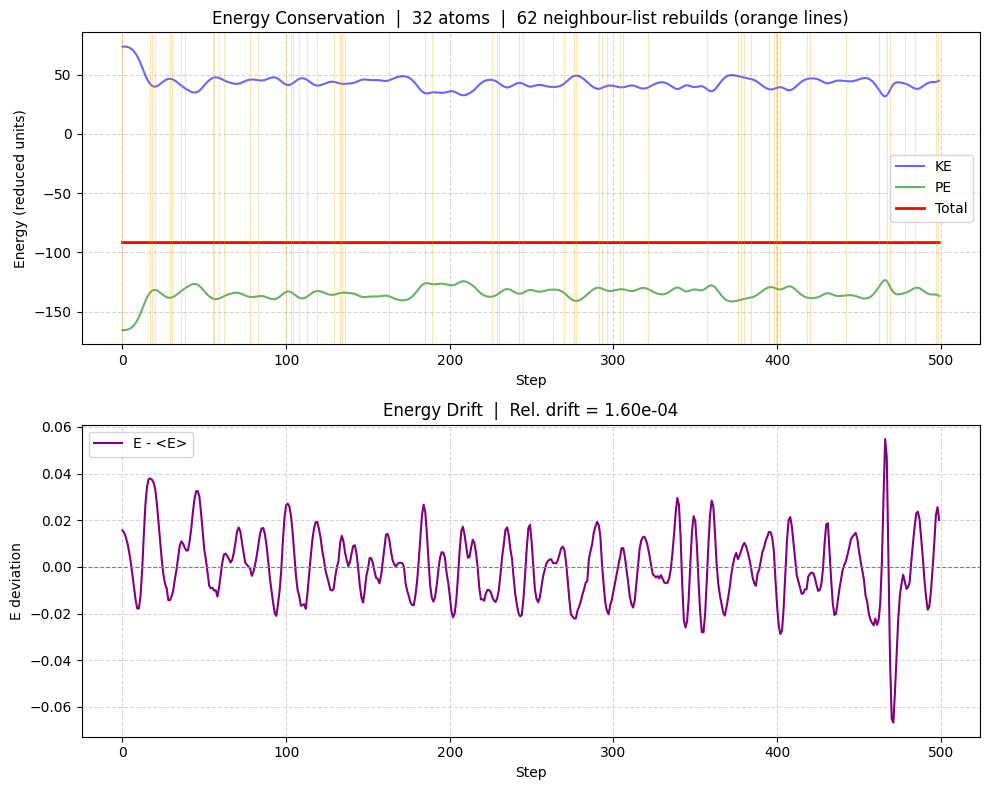

Mean E: -91.6637   Std: 0.014688   Rel drift: 1.60e-04


In [70]:
import numpy as np
import matplotlib.pyplot as plt

# --- Setup: FCC lattice with 32 atoms (n_cells=2) ---
n_cells    = 2         # 4 * 2^3 = 32 atoms
rho_star   = 0.8
r_cutoff   = 2.5;  r_cutoff_sq = r_cutoff**2
r_skin     = 3.2;  r_skin_sq   = r_skin**2    # skin > cutoff by 0.7
dt         = 0.005
n_steps    = 500

pos, L = generate_fcc_lattice(n_cells, rho_star)
vel = np.random.randn(*pos.shape) * np.sqrt(1.5)   # T* ~ 1.5
vel -= vel.mean(axis=0)

pos_ref = pos.copy()
neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
pe, force = calculate_forces_optimized(pos, neighbour_list, L, r_cutoff_sq)

rebuild_threshold_sq = 0.25 * (r_skin - r_cutoff)**2   # (0.7/2)^2 = 0.1225
print('N atoms:', len(pos), '  Box:', round(L, 3), '  Rebuild threshold:', round(rebuild_threshold_sq**0.5, 4))
print('Initial neighbour pairs:', len(neighbour_list))

ke_list, pe_list, total_e_list = [], [], []
rebuild_count = 0
rebuild_steps = []

for step in range(n_steps):
    pos, vel, pe, force = velocity_verlet_step_opt(pos, vel, force, dt, L, r_cutoff_sq, neighbour_list)
    ke = calculate_kinetic_energy(vel)
    ke_list.append(ke); pe_list.append(pe); total_e_list.append(ke + pe)

    # Rebuild if any atom has drifted > (r_skin - r_cutoff)/2 from snapshot
    disp_sq = np.sum((pos - pos_ref)**2, axis=1)
    if np.any(disp_sq > rebuild_threshold_sq):
        rebuild_count += 1
        rebuild_steps.append(step)
        neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
        pos_ref = pos.copy()

print('Total rebuilds in', n_steps, 'steps:', rebuild_count)
print('Rebuild at steps:', rebuild_steps[:10], '...' if len(rebuild_steps) > 10 else '')

# --- Plotting ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

steps_arr = np.arange(n_steps)
ax = axes[0]
ax.plot(steps_arr, ke_list,      label='KE',    color='blue',  alpha=0.6)
ax.plot(steps_arr, pe_list,      label='PE',    color='green', alpha=0.6)
ax.plot(steps_arr, total_e_list, label='Total', color='red',   linewidth=2)
for s in rebuild_steps:
    ax.axvline(s, color='orange', alpha=0.3, linewidth=0.8)
ax.set_xlabel('Step'); ax.set_ylabel('Energy (reduced units)')
ax.set_title('Energy Conservation  |  ' + str(len(pos)) + ' atoms  |  ' + str(rebuild_count) + ' neighbour-list rebuilds (orange lines)')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.5)

E = np.array(total_e_list)
E_dev = E - E.mean()
ax2 = axes[1]
ax2.plot(steps_arr, E_dev, color='purple', linewidth=1.5, label='E - <E>')
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xlabel('Step'); ax2.set_ylabel('E deviation')
ax2.set_title('Energy Drift  |  Rel. drift = ' + '{:.2e}'.format(E.std()/abs(E.mean())))
ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("m4_energy_rebuild.pdf", dpi=300)
plt.show()
print('Mean E:', round(E.mean(), 4), '  Std:', round(E.std(), 6), '  Rel drift:', '{:.2e}'.format(E.std()/abs(E.mean())))


### Comparing runtimes between Force Calculations pre- and post-Neighbour List optimization

In [71]:
import time
import numpy as np

rho_star   = 0.8
r_cutoff   = 2.5;  r_cutoff_sq = r_cutoff**2
r_skin     = 3.2;  r_skin_sq   = r_skin**2
REPS       = 20     # repetitions for stable timing

configs = [
    (3, "108 (n=3)"),
    (4, "256 (n=4)"),
    (5, "500 (n=5)"),
    (6, "864 (n=6)"),
]

print(f"{'N':<14} {'Total pairs':>12} {'Skin-list pairs':>16} {'Naive (ms)':>12} {'Optimised (ms)':>16} {'Speedup':>10}")
print("-" * 84)

for n_cells, label in configs:
    pos, L = generate_fcc_lattice(n_cells, rho_star)
    N = len(pos)
    total_pairs = N * (N - 1) // 2

    # Build neighbour list once
    neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
    skin_pairs = len(neighbour_list)

    # --- Time naive ---
    t0 = time.perf_counter()
    for _ in range(REPS):
        calculate_total_force(pos, L, r_cutoff_sq)
    naive_ms = (time.perf_counter() - t0) / REPS * 1e3

    # --- Time optimised ---
    t0 = time.perf_counter()
    for _ in range(REPS):
        calculate_forces_optimized(pos, neighbour_list, L, r_cutoff_sq)
    opt_ms = (time.perf_counter() - t0) / REPS * 1e3

    speedup = naive_ms / opt_ms
    print(f"{label:<14} {total_pairs:>12,} {skin_pairs:>16,} {naive_ms:>12.2f} {opt_ms:>16.2f} {speedup:>9.1f}x")

N               Total pairs  Skin-list pairs   Naive (ms)   Optimised (ms)    Speedup
------------------------------------------------------------------------------------
108 (n=3)             5,778            5,292         1.30             0.65       2.0x
256 (n=4)            32,640           17,152         6.49             2.82       2.3x
500 (n=5)           124,750           33,500        35.58             5.25       6.8x
864 (n=6)           372,816           57,888       133.02             9.16      14.5x


### Comparing Energies calculated pre- and post-Neighbour List optimizations

In [72]:
rho_star    = 0.8
r_cutoff    = 2.5;  r_cutoff_sq = r_cutoff**2
r_skin      = 3.2;  r_skin_sq   = r_skin**2

configs = [
    (3, 108),
    (4, 256),
    (5, 500),
]

print(f"{'N':<6} {'E*_naive':>12} {'E*_opt':>12} {'|ΔE*|':>12}")
print("-" * 46)

for n_cells, N in configs:
    pos, L = generate_fcc_lattice(n_cells, rho_star)

    pe_naive, _ = calculate_total_force(pos, L, r_cutoff_sq)

    neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
    pe_opt, _    = calculate_forces_optimized(pos, neighbour_list, L, r_cutoff_sq)

    delta = abs(pe_naive - pe_opt)
    delta_str = f"< 10⁻⁸" if delta < 1e-8 else f"{delta:.2e}"

    print(f"{N:<6} {pe_naive:>12.4g} {pe_opt:>12.4g} {delta_str:>12}")

N          E*_naive       E*_opt        |ΔE*|
----------------------------------------------
108          -586.3       -586.3       < 10⁻⁸
256           -1390        -1390       < 10⁻⁸
500           -2715        -2715       < 10⁻⁸
